# LastFM Feature Extraction

Builds `surv_logs_last.csv` and `events.csv` in the loader-compatible format
expected by `get_churn_lastfm_dataset_months` (utils.py:182).

In [2]:
# Cell 1 – Config
import os

# Path to the raw LastFM-1K TSV (userid-timestamp-artid-artname-traid-traname.tsv)
RAW_TSV_PATH = "/Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv"

# Output directory – matches config_lastfm.yaml data_path so utils.py needs no changes
OUTPUT_DIR = "/Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"RAW_TSV_PATH : {RAW_TSV_PATH}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")

RAW_TSV_PATH : /Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K/userid-timestamp-artid-artname-traid-traname.tsv
OUTPUT_DIR   : /Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K


In [3]:
# Cell 2 – Load raw TSV
# Columns: userid  timestamp  artid  artname  traid  traname
# Some rows have embedded tabs in artist/track names → on_bad_lines='skip'
import pandas as pd

df_raw = pd.read_csv(
    RAW_TSV_PATH,
    sep="\t",
    header=None,
    names=["user", "timestamp", "artist_id", "artist", "track_id", "song"],
    usecols=[0, 1, 3, 5],
    encoding="utf-8",
    encoding_errors="replace",
    on_bad_lines="skip",
)
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True, errors="coerce")
df_raw = df_raw.dropna(subset=["timestamp"])
print(f"Loaded {len(df_raw):,} events from {df_raw['user'].nunique():,} users")
df_raw.head()

Loaded 19,098,862 events from 992 users


,user,timestamp,artist,song
0,user_000001,2009-05-04 23:08:57+00:00,Deep Dish,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04 13:54:10+00:00,坂本龍一,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04 13:52:04+00:00,坂本龍一,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04 13:42:52+00:00,坂本龍一,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04 13:42:11+00:00,坂本龍一,Mc1 (Live_2009_4_15)


In [4]:
# Cell 3 – Weekly windows
import numpy as np
from scipy.stats import entropy as scipy_entropy

# Assign ISO-week bucket (Monday-start) as a Period
df_raw["week"] = df_raw["timestamp"].dt.to_period("W-MON")
df_sorted = df_raw.sort_values(["user", "timestamp"])

def compute_weekly_features(user_df):
    """Return per-week feature DataFrame for a single user."""
    user_df = user_df.sort_values("timestamp").reset_index(drop=True)
    song_prior = {}
    repeat_flags = []
    novelty_scores = []
    for _, row in user_df.iterrows():
        s = row["song"]
        cnt = song_prior.get(s, 0)
        repeat_flags.append(cnt > 0)
        novelty_scores.append(1.0 / (1.0 + cnt))
        song_prior[s] = cnt + 1
    user_df = user_df.copy()
    user_df["repeat"] = repeat_flags
    user_df["novelty_row"] = novelty_scores
    weekly_rows = []
    for week, wdf in user_df.groupby("week", sort=True):
        artist_counts = wdf["artist"].value_counts()
        artist_probs = artist_counts / artist_counts.sum()
        weekly_rows.append({
            "week": week,
            "listen_count": len(wdf),
            "unique_artists": wdf["artist"].nunique(),
            "artist_entropy": float(scipy_entropy(artist_probs)),
            "repeat_ratio": float(wdf["repeat"].mean()),
            "novelty": float(wdf["novelty_row"].mean()),
        })
    return pd.DataFrame(weekly_rows)

print("Computing weekly features (may take a few minutes)...")
weekly_parts = []
for user, udf in df_sorted.groupby("user"):
    wf = compute_weekly_features(udf)
    wf["userid"] = user
    weekly_parts.append(wf)

df_weekly = pd.concat(weekly_parts, ignore_index=True)
df_weekly = df_weekly.sort_values(["userid", "week"]).reset_index(drop=True)

feat_cols = ["listen_count", "unique_artists", "artist_entropy", "repeat_ratio", "novelty"]
for col in feat_cols:
    df_weekly[f"delta_{col}"] = df_weekly.groupby("userid")[col].diff().fillna(0)

print(f"Weekly feature table: {df_weekly.shape}")
df_weekly.head()

/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_21169/2029674946.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_raw["week"] = df_raw["timestamp"].dt.to_period("W-MON")


Computing weekly features (may take a few minutes)...
Weekly feature table: (83479, 12)


,week,listen_count,unique_artists,artist_entropy,repeat_ratio,novelty,userid,delta_listen_count,delta_unique_artists,delta_artist_entropy,delta_repeat_ratio,delta_novelty
0,2006-08-08/2006-08-14,51,24,2.371608,0.039216,0.977124,user_000001,0.0,0.0,0.000000,0.000000,0.000000
1,2006-08-15/2006-08-21,247,60,2.357186,0.506073,0.645355,user_000001,196.0,36.0,-0.014422,0.466857,-0.331769
2,2006-08-22/2006-08-28,100,21,1.666015,0.790000,0.369943,user_000001,-147.0,-39.0,-0.691171,0.283927,-0.275413
3,2006-08-29/2006-09-04,161,18,2.130146,0.627329,0.604076,user_000001,61.0,-3.0,0.464130,-0.162671,0.234133
4,2006-09-05/2006-09-11,252,25,2.234485,0.714286,0.442855,user_000001,91.0,7.0,0.104339,0.086957,-0.161221


<Axes: >

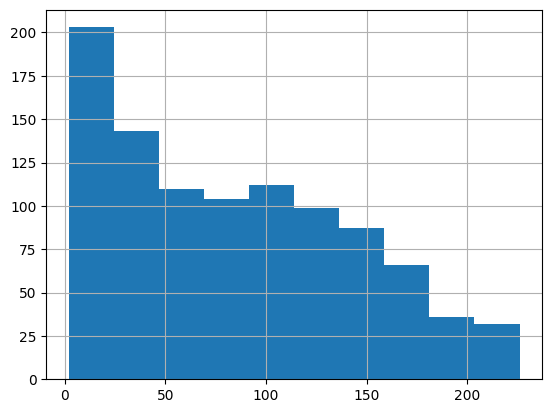

In [5]:
df_weekly.groupby('userid').size().hist()

In [6]:
# Cell 4 – Churn indicator
# The dataset covers listening history up to May 5, 2009.
# A user churns if they have no listens in the 4-week window immediately
# before that date (~1 month). Users active in that window are censored.
#
# time = number of active weeks (= sequence length), so time and sequence
# rows are always in the same unit. For censored users this is the total
# number of weeks they were observed; the loader sets horizon = max(ts).

DATASET_END_WEEK = pd.Period("2009-05-05", "W-MON")  # week containing May 5 2009
CHURN_LOOKBACK = 1  # weeks (~1 month)

def compute_churn(user_df):
    user_df = user_df.sort_values("week").reset_index(drop=True)
    all_weeks = pd.period_range(user_df["week"].min(), DATASET_END_WEEK, freq="W-MON")
    active_weeks = set(user_df["week"])
    final_weeks = set(all_weeks[-CHURN_LOOKBACK:])
    churned = len(active_weeks & final_weeks) == 0
    return {"time": len(user_df), "censored": not churned}

event_rows = []
for user, udf in df_weekly.groupby("userid"):
    res = compute_churn(udf)
    res["userid"] = user
    event_rows.append(res)

df_events = pd.DataFrame(event_rows)[["userid", "time", "censored"]]
churn_rate = (~df_events["censored"]).mean()
print(f"Events table: {df_events.shape}, churn rate: {churn_rate:.2%}")
df_events.head()

Events table: (992, 3), churn rate: 85.79%


,userid,time,censored
0,user_000001,104,False
1,user_000002,156,False
2,user_000003,135,False
3,user_000004,93,False
4,user_000005,121,False


In [7]:
# Cell 5 – Survival format panel
df_weekly["week_idx"] = df_weekly.groupby("userid").cumcount()
df_weekly["t_start"] = df_weekly["week_idx"]
df_weekly["t_stop"] = df_weekly["week_idx"] + 1

df_panel = df_weekly.merge(df_events[["userid", "time", "censored"]], on="userid", how="left")
df_panel["churn"] = (~df_panel["censored"]) & (df_panel["t_stop"] == df_panel["time"])

panel_cols = [
    "userid", "week_idx", "t_start", "t_stop", "churn",
    "listen_count", "unique_artists", "artist_entropy", "repeat_ratio", "novelty",
    "delta_listen_count", "delta_unique_artists", "delta_artist_entropy",
    "delta_repeat_ratio", "delta_novelty",
]
df_panel = df_panel[panel_cols]
print(f"Panel shape: {df_panel.shape}")
df_panel.head()

Panel shape: (83479, 15)


,userid,week_idx,t_start,t_stop,churn,listen_count,unique_artists,artist_entropy,repeat_ratio,novelty,delta_listen_count,delta_unique_artists,delta_artist_entropy,delta_repeat_ratio,delta_novelty
0,user_000001,0,0,1,False,51,24,2.371608,0.039216,0.977124,0.0,0.0,0.000000,0.000000,0.000000
1,user_000001,1,1,2,False,247,60,2.357186,0.506073,0.645355,196.0,36.0,-0.014422,0.466857,-0.331769
2,user_000001,2,2,3,False,100,21,1.666015,0.790000,0.369943,-147.0,-39.0,-0.691171,0.283927,-0.275413
3,user_000001,3,3,4,False,161,18,2.130146,0.627329,0.604076,61.0,-3.0,0.464130,-0.162671,0.234133
4,user_000001,4,4,5,False,252,25,2.234485,0.714286,0.442855,91.0,7.0,0.104339,0.086957,-0.161221


In [8]:
# Cell 6 – Save in loader-compatible format
# surv_logs_last.csv: userid + numeric feature columns (index becomes 'Unnamed: 0', dropped by loader)
# events.csv: time, censored (one row per user, order matches surv_logs groupby)

surv_log_cols = [
    "userid",
    "listen_count", "unique_artists", "artist_entropy", "repeat_ratio", "novelty",
    "delta_listen_count", "delta_unique_artists", "delta_artist_entropy",
    "delta_repeat_ratio", "delta_novelty", "week_idx"
]
df_surv_logs = df_panel[surv_log_cols].sort_values(["userid", "week_idx"] if "week_idx" in df_panel.columns else ["userid"])

# events.csv must be aligned with the groupby order used by the loader
ordered_users = df_surv_logs.groupby("userid").first().index
df_events_out = df_events.set_index("userid").loc[ordered_users][["time", "censored"]].reset_index(drop=True)

surv_logs_path = os.path.join(OUTPUT_DIR, "surv_logs_last.csv")
events_path = os.path.join(OUTPUT_DIR, "events.csv")

df_surv_logs.to_csv(surv_logs_path, index=True)
df_events_out.to_csv(events_path, index=False)

print(f"Saved surv_logs_last.csv : {df_surv_logs.shape}  ->  {surv_logs_path}")
print(f"Saved events.csv         : {df_events_out.shape}  ->  {events_path}")

Saved surv_logs_last.csv : (83479, 12)  ->  /Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K/surv_logs_last.csv
Saved events.csv         : (992, 2)  ->  /Users/mariana/Documents/projects/survival_analysis/data/lastfm-dataset-1K/events.csv


=== surv_logs_last.csv ===
  shape      : (83479, 12)
  users      : 992
  NaN count  : 0

=== events.csv ===
  shape      : (992, 2)
  churn rate : 85.79%
  time range : 2 – 226 weeks

=== Feature distributions ===


,listen_count,unique_artists,artist_entropy,repeat_ratio,novelty,delta_listen_count,delta_unique_artists,delta_artist_entropy,delta_repeat_ratio,delta_novelty,week_idx
count,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000,83479.000000
mean,228.786425,58.034404,2.834699,0.699085,0.452535,-1.086621,-0.229986,-0.013303,0.003456,-0.003023,62.341080
std,277.673925,79.300593,1.274452,0.272568,0.255400,192.299735,51.633678,1.040526,0.221990,0.185786,47.392607
min,1.000000,1.000000,0.000000,0.000000,0.002924,-3082.000000,-1217.000000,-6.823933,-1.000000,-0.984127,0.000000
25%,53.000000,13.000000,2.022809,0.546815,0.246886,-65.000000,-15.000000,-0.524589,-0.077306,-0.089053,23.000000
50%,144.000000,33.000000,2.914393,0.782828,0.411807,0.000000,0.000000,0.000000,0.002324,-0.005917,53.000000
75%,300.000000,74.000000,3.727939,0.916667,0.631851,62.500000,15.000000,0.500402,0.093573,0.074451,93.000000
max,4159.000000,1576.000000,7.273605,1.000000,1.000000,3977.000000,1541.000000,6.167402,1.000000,0.987859,225.000000


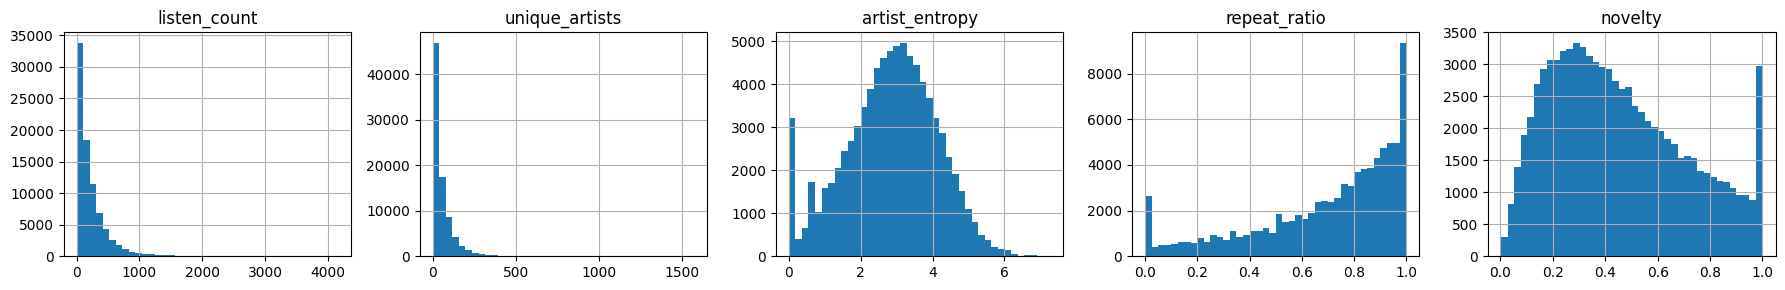

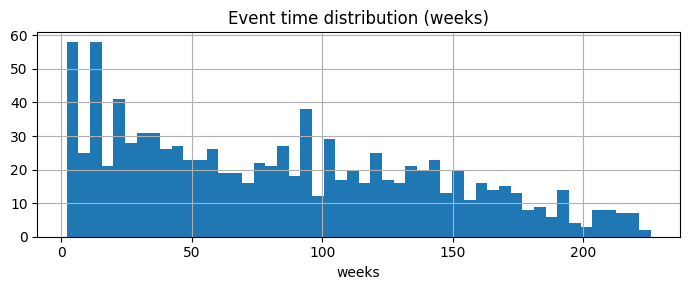

In [9]:
# Cell 7 – Quick sanity checks
import matplotlib.pyplot as plt

print("=== surv_logs_last.csv ===")
print(f"  shape      : {df_surv_logs.shape}")
print(f"  users      : {df_surv_logs['userid'].nunique()}")
print(f"  NaN count  : {df_surv_logs.isnull().sum().sum()}")
print()
print("=== events.csv ===")
print(f"  shape      : {df_events_out.shape}")
print(f"  churn rate : {(~df_events_out['censored']).mean():.2%}")
print(f"  time range : {df_events_out['time'].min()} – {df_events_out['time'].max()} weeks")
print()
print("=== Feature distributions ===")
display(df_surv_logs.describe())

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, ["listen_count", "unique_artists", "artist_entropy", "repeat_ratio", "novelty"]):
    df_surv_logs[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 3))
df_events_out["time"].hist(bins=50, ax=ax2)
ax2.set_title("Event time distribution (weeks)")
ax2.set_xlabel("weeks")
plt.tight_layout()
plt.show()

In [10]:
df_surv_logs

,userid,listen_count,unique_artists,artist_entropy,repeat_ratio,novelty,delta_listen_count,delta_unique_artists,delta_artist_entropy,delta_repeat_ratio,delta_novelty,week_idx
0,user_000001,51,24,2.371608,0.039216,0.977124,0.0,0.0,0.000000,0.000000,0.000000,0
1,user_000001,247,60,2.357186,0.506073,0.645355,196.0,36.0,-0.014422,0.466857,-0.331769,1
2,user_000001,100,21,1.666015,0.790000,0.369943,-147.0,-39.0,-0.691171,0.283927,-0.275413,2
3,user_000001,161,18,2.130146,0.627329,0.604076,61.0,-3.0,0.464130,-0.162671,0.234133,3
4,user_000001,252,25,2.234485,0.714286,0.442855,91.0,7.0,0.104339,0.086957,-0.161221,4
...,...,...,...,...,...,...,...,...,...,...,...,...
83474,user_001000,371,33,2.982733,0.824798,0.380096,191.0,10.0,-0.071028,-0.119647,0.105157,58
83475,user_001000,151,36,2.495091,0.761589,0.419677,-220.0,3.0,-0.487642,-0.063208,0.039581,59
83476,user_001000,285,34,2.862420,0.919298,0.281357,134.0,-2.0,0.367328,0.157709,-0.138319,60
83477,user_001000,363,66,3.276854,0.892562,0.290802,78.0,32.0,0.414434,-0.026736,0.009445,61


In [11]:
df_events_out.time.max()

226

In [17]:
from sklearn.discriminant_analysis import StandardScaler

numeric_columns = ['listen_count',
                       'unique_artists',	'artist_entropy',	'repeat_ratio',	'novelty',	'delta_listen_count',
                       'delta_unique_artists',	'delta_artist_entropy',	'delta_repeat_ratio',	'delta_novelty']

scaler = StandardScaler()
df_logs = df_surv_logs.copy()
df_logs[numeric_columns] = scaler.fit_transform(
    df_logs[numeric_columns])

In [18]:
df_logs

,userid,listen_count,unique_artists,artist_entropy,repeat_ratio,novelty,delta_listen_count,delta_unique_artists,delta_artist_entropy,delta_repeat_ratio,delta_novelty,week_idx
0,user_000001,-0.640274,-0.429185,-0.363367,-2.420945,2.054005,0.005651,0.004454,0.012785,-0.015570,0.016270,0
1,user_000001,0.065594,0.024787,-0.374683,-0.708127,0.754979,1.024899,0.701678,-0.001075,2.087494,-1.769495,1
2,user_000001,-0.463807,-0.467016,-0.917014,0.333553,-0.323387,-0.758786,-0.750871,-0.651470,1.263444,-1.466155,2
3,user_000001,-0.244124,-0.504847,-0.552832,-0.263259,0.593352,0.322866,-0.053648,0.458842,-0.748358,1.276507,3
4,user_000001,0.083601,-0.416574,-0.470962,0.055770,-0.037902,0.478873,0.140025,0.113061,0.376145,-0.851511,4
...,...,...,...,...,...,...,...,...,...,...,...,...
83474,user_001000,0.512163,-0.315692,0.116155,0.461220,-0.283633,0.998898,0.198127,-0.055477,-0.554546,0.582284,58
83475,user_001000,-0.280138,-0.277861,-0.266475,0.229319,-0.128656,-1.138403,0.062556,-0.455866,-0.300307,0.229317,59
83476,user_001000,0.202446,-0.303082,0.021751,0.807925,-0.670240,0.702484,-0.034280,0.365809,0.694865,-0.728242,60
83477,user_001000,0.483352,0.100449,0.346939,0.709835,-0.633258,0.411270,0.624208,0.411081,-0.136010,0.067109,61
